In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import string
import re
import nltk
nltk.download('punkt')
nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


In [9]:
from nltk.probability import FreqDist
import pymorphy3

In [53]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

In [3]:
with open('2011.txt', 'r') as file:
    data = file.read()

In [5]:
data

'1. Мы, главы государств и правительств Федеративной Республики Бразилия, Российской Федерации, Республики Индия, Китайской Народной Республики и Южно-Африканской Республики, собрались на встречу лидеров БРИКС в г. Санья, о. Хайнань, Китай, 14 апреля 2011 года.\n2. Главы государств и правительств Бразилии, России, Индии и Китая приветствуют вступление в БРИКС Южной Африки и выражают надежду на укрепление диалога и сотрудничества с Южной Африкой в рамках нашего Форума.\n3. Видение общей цели и сильное общее стремление к миру, безопасности, развитию и сотрудничеству объединило страны БРИКС с населением почти 3 млрд. человек на разных континентах. БРИКС стремится внести значительный вклад в развитие человечества и создание более равноправного и справедливого мира.\n4. XXI век должен характеризоваться миром, гармонией, сотрудничеством и развитием на основе достижений науки. В рамках темы «Широкое видение, общее процветание» мы провели откровенные и углубленные обсуждения и достигли широког

In [11]:
stop_words = stopwords.words('russian')
morph = pymorphy3.MorphAnalyzer()

In [13]:
def tokenize_text(raw_text: str):
    """Функция для токенизации текста
    :param raw_text: исходная текстовая строка
    """
    # Разбиение на сслова при помощи пробела
    words = raw_text.split()
    # Подготовка регулярного выражения для фильтрации символов
    re_punc = re.compile('[%s]' % re.escape(string.punctuation))
    # Удаление знаков препинания
    stripped = [re_punc.sub('', w) for w in words]
    # Приведение всех слов к нижнему регистру
    words_lower = [w.lower() for w in stripped]
    # Удаление оставшихся токенов, которые не являются буквами
    words_alpha = [word for word in words_lower if word.isalpha()]
    # Удаление стоп-слов    
    words_stop = [w for w in words_alpha if not w in stop_words]
    # Лемматизация    
    tokens = [morph.parse(token)[0].normal_form for token in words_stop]
    # Удалим короткие токены
    tokens = [word for word in tokens if len(word) > 2]
      
    return tokens

In [15]:
tokenized = tokenize_text(data)

In [37]:
all_words = FreqDist(tokenized)

In [39]:
print("Наиболлее популярные слова: ", all_words.most_common(100))
print("\nОбщее количество уникальных слов: ", len(all_words.keys()))

Наиболлее популярные слова:  [('сотрудничество', 41), ('брикс', 36), ('международный', 32), ('развитие', 28), ('страна', 28), ('год', 23), ('китай', 17), ('африка', 16), ('экономика', 16), ('проведение', 16), ('вопрос', 15), ('бразилия', 14), ('встреча', 14), ('поддерживать', 13), ('индия', 12), ('россия', 12), ('южный', 12), ('укрепление', 12), ('рамка', 12), ('наш', 11), ('мир', 11), ('безопасность', 11), ('глобальный', 11), ('организация', 11), ('оон', 11), ('цель', 10), ('должный', 10), ('достижение', 10), ('также', 10), ('экономический', 10), ('рост', 10), ('финансовый', 10), ('выражать', 9), ('общий', 9), ('роль', 9), ('решение', 9), ('который', 9), ('государство', 8), ('дальнейший', 8), ('система', 8), ('основа', 7), ('сфера', 7), ('изменение', 7), ('действие', 7), ('призывать', 7), ('устойчивый', 7), ('новый', 7), ('принять', 7), ('конференция', 7), ('объединить', 6), ('подтверждать', 6), ('многосторонний', 6), ('сторона', 6), ('мировой', 6), ('сообщество', 6), ('усилие', 6), (

C:\Temp\ipykernel_1496\1563493910.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


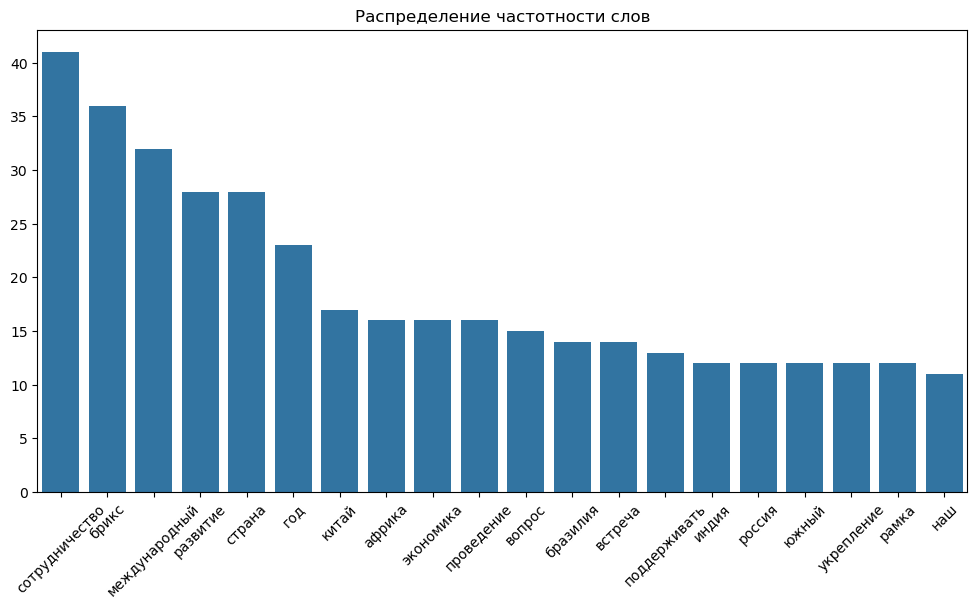

In [45]:
count, words = [], []
for w in all_words.most_common(20):
    words.append(w[0])
    count.append(w[1])
fig,ax = plt.subplots(figsize = (12,6))
ax = sns.barplot(x=words,y=count)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.set_title ('Распределение частотности слов')
plt.show()

In [79]:
stop_words_ex = ['год','наш', 'который', 'также']
def stop_words_extra(text):
    return [w for w in text if not w in stop_words_ex]

In [81]:
tokens = stop_words_extra(tokenized)

C:\Temp\ipykernel_1496\3051857113.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


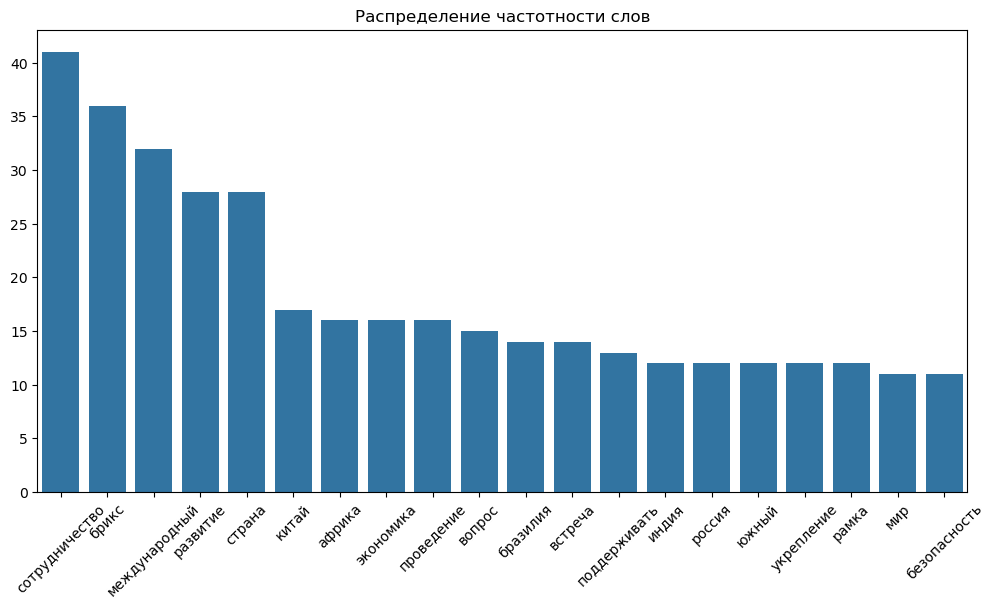

In [83]:
all_words = FreqDist(tokens)
count, words = [], []
for w in all_words.most_common(20):
    words.append(w[0])
    count.append(w[1])
fig,ax = plt.subplots(figsize = (12,6))
ax = sns.barplot(x=words,y=count)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.set_title ('Распределение частотности слов')
plt.show()

In [85]:
textt = ','.join(w for w in tokens)

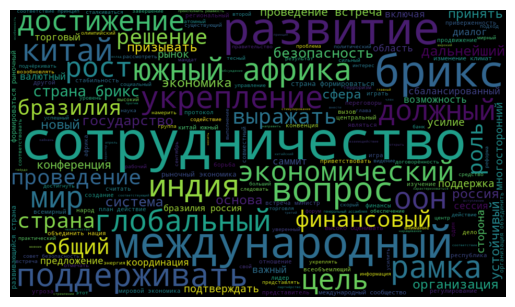

In [87]:
wordcloud = WordCloud(width=950,height=550).generate(textt)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [91]:
# Приводим текст в векторное представление
tfidf_vect = TfidfVectorizer(max_df=1.0, min_df=2, stop_words=None)
doc_term_matrix = tfidf_vect.fit_transform(tokens)

### Латентное размещение Дерихле

In [95]:
LDA = LatentDirichletAllocation(n_components=2, random_state=42)
LDA.fit(doc_term_matrix)

LatentDirichletAllocation(n_components=2, random_state=42)

In [99]:
for i,topic in enumerate(LDA.components_):
    print(f'Top 10 words for topic #{i}:')
    print([tfidf_vect.get_feature_names_out()[i] for i in topic.argsort()[-10:]])
    print('\n')

Top 10 words for topic #0:
['экономический', 'оон', 'мир', 'глобальный', 'организация', 'укрепление', 'россия', 'южный', 'встреча', 'экономика']


Top 10 words for topic #1:
['бразилия', 'вопрос', 'африка', 'проведение', 'китай', 'развитие', 'страна', 'международный', 'брикс', 'сотрудничество']




In [101]:
LDA = LatentDirichletAllocation(n_components=3, random_state=42)
LDA.fit(doc_term_matrix)
for i,topic in enumerate(LDA.components_):
    print(f'Top 10 words for topic #{i}:')
    print([tfidf_vect.get_feature_names_out()[i] for i in topic.argsort()[-10:]])
    print('\n')

Top 10 words for topic #0:
['выражать', 'роль', 'цель', 'глобальный', 'организация', 'оон', 'южный', 'россия', 'укрепление', 'экономика']


Top 10 words for topic #1:
['рост', 'финансовый', 'рамка', 'индия', 'вопрос', 'проведение', 'африка', 'развитие', 'страна', 'международный']


Top 10 words for topic #2:
['достижение', 'экономический', 'безопасность', 'мир', 'поддерживать', 'бразилия', 'встреча', 'китай', 'брикс', 'сотрудничество']




### Неотрицательная матричная факторизация

In [108]:
nmf = NMF(n_components=2, random_state=42)
nmf.fit(doc_term_matrix )
for i,topic in enumerate(nmf.components_):
    print(f'Top 10 words for topic #{i}:')
    print([tfidf_vect.get_feature_names_out()[i] for i in topic.argsort()[-10:]])
    print('\n')

Top 10 words for topic #0:
['укрепление', 'экономика', 'бразилия', 'поддерживать', 'вопрос', 'африка', 'китай', 'встреча', 'международный', 'сотрудничество']


Top 10 words for topic #1:
['рамка', 'индия', 'экономика', 'вопрос', 'китай', 'проведение', 'страна', 'развитие', 'международный', 'брикс']




Вывод: тематика декларации 2011 г. посвящена общим вопросам международного сотрудничества